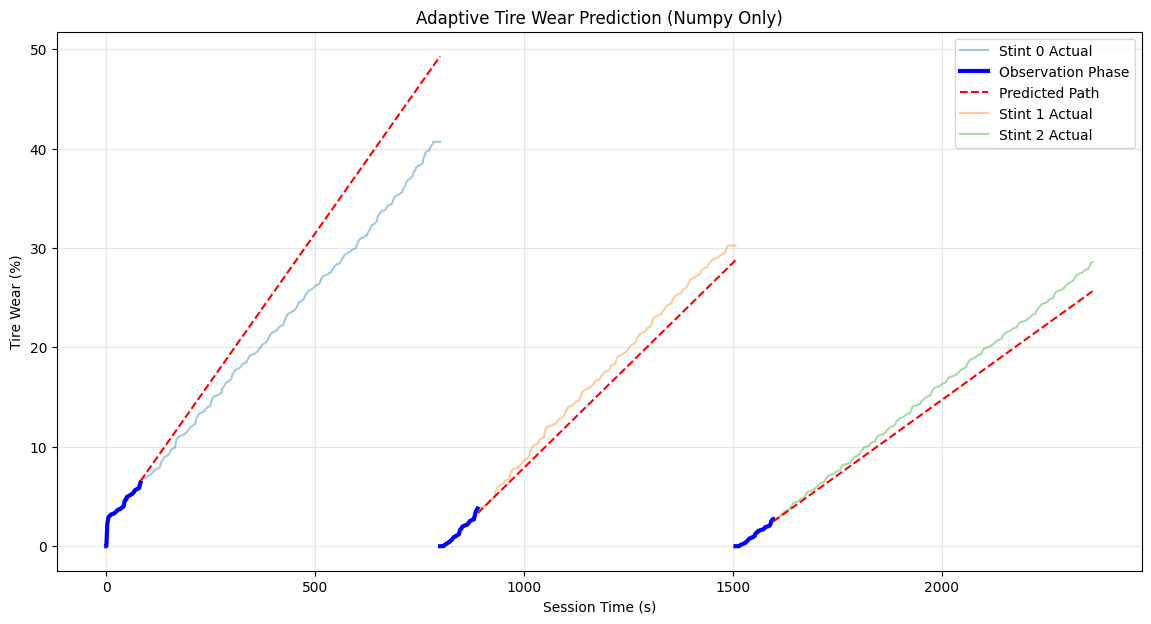

In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def test_adaptive_prediction_no_sklearn(filepath, observation_minutes=1.5):
    # 1. 데이터 로드 및 전처리
    data_list = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                p_idx = d['m_header']['m_playerCarIndex']
                data_list.append({
                    'time': d['m_header']['m_sessionTime'],
                    'wear': d['m_carDamageData'][p_idx]['m_tyresWear'][0] 
                })
            except: continue
    
    df = pd.DataFrame(data_list)
    if df.empty: return print("데이터가 없습니다.")

    # 2. 피트스톱 감지 (마모도가 5% 이상 갑자기 줄어들면 새 타이어로 간주)
    df['stint'] = (df['wear'].diff() < -5).cumsum()
    
    plt.figure(figsize=(14, 7))
    
    # 3. 각 스틴트(Stint)별로 실험
    for stint_id, group in df.groupby('stint'):
        if len(group) < 500: continue
        
        group = group.reset_index(drop=True)
        
        # 관찰 윈도우 설정 (10Hz 기준)
        obs_limit = int(observation_minutes * 60 * 10)
        if len(group) <= obs_limit: continue
        
        obs_data = group.iloc[:obs_limit]
        future_data = group.iloc[obs_limit:]
        
        # [핵심] numpy.polyfit으로 선형 회귀 계산 ($y = ax + b$)
        # z[0]은 기울기(a), z[1]은 절편(b)이 됩니다.
        z = np.polyfit(obs_data['time'], obs_data['wear'], 1)
        predict_fn = np.poly1d(z)
        
        # 미래 데이터 예측
        y_pred = predict_fn(future_data['time'])
        
        # 4. 시각화
        plt.plot(group['time'], group['wear'], label=f'Stint {stint_id} Actual', alpha=0.4)
        plt.plot(obs_data['time'], obs_data['wear'], color='blue', linewidth=3, label='Observation Phase' if stint_id==0 else "")
        plt.plot(future_data['time'], y_pred, color='red', linestyle='--', label='Predicted Path' if stint_id==0 else "")

    plt.title(f"Adaptive Tire Wear Prediction (Numpy Only)")
    plt.xlabel("Session Time (s)")
    plt.ylabel("Tire Wear (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 실행
test_adaptive_prediction_no_sklearn(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl', observation_minutes=1.5)

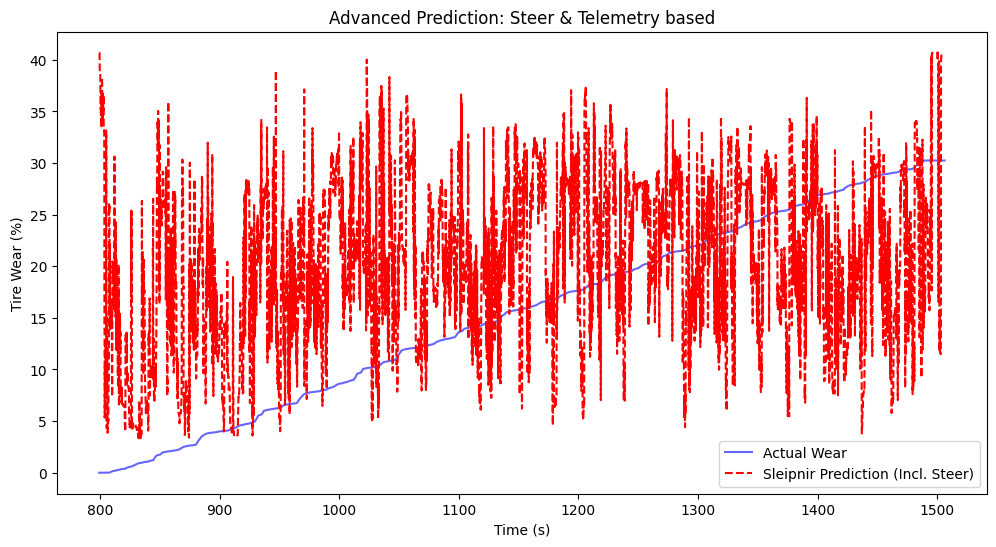

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor # 비선형성 대응을 위해 모델 변경
from sklearn.preprocessing import StandardScaler

def load_and_flatten(file_path, p_type):
    rows = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                h = d['m_header']
                idx = h['m_playerCarIndex']
                t = h['m_sessionTime']
                
                row = {'time': t}
                if p_type == 'damage':
                    row['wear'] = d['m_carDamageData'][idx]['m_tyresWear'][0]
                elif p_type == 'tele':
                    data = d['m_carTelemetryData'][idx]
                    row['brake'] = data['m_brake']
                    row['steer'] = data['m_steer'] # 조향각 추가 (-1.0 ~ 1.0)
                    row['speed'] = data['m_speed']
                    row['temp'] = data['m_tyresSurfaceTemperature'][0]
                elif p_type == 'motion':
                    row['g_lat'] = abs(d['m_carMotionData'][idx]['m_gForceLateral'])
                rows.append(row)
            except: continue
    return pd.DataFrame(rows).sort_values('time')

# 1. 데이터 로드 및 병합
df_d = load_and_flatten(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl', 'damage')
df_t = load_and_flatten(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl', 'tele')
df_m = load_and_flatten(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl', 'motion')

combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
combined = pd.merge_asof(combined, df_m, on='time', direction='nearest').dropna()

# 2. 피처 엔지니어링: 물리적 에너지(Work Done) 계산
# 조향 에너지: abs(조향각) * 속도 (타이어를 비비는 에너지)
combined['steer_work'] = abs(combined['steer']) * combined['speed']
# 브레이크 에너지: 브레이크 * 속도
combined['brake_work'] = combined['brake'] * combined['speed']
# 횡가속도 에너지
combined['glat_work'] = combined['g_lat'] * combined['speed']

# [중요] 노이즈 제거: 5초(50틱) 이동 평균 적용
window = 50
combined['steer_smooth'] = combined['steer_work'].rolling(window).mean()
combined['brake_smooth'] = combined['brake_work'].rolling(window).mean()
combined['temp_smooth'] = combined['temp'].rolling(window).mean()
combined = combined.dropna()

# 3. 모델 학습 및 예측
# 마모도가 0으로 떨어지는 구간(피트인)을 기준으로 데이터 분할
combined['stint'] = (combined['wear'].diff() < -5).cumsum()

# 첫 번째 스틴트로 학습, 두 번째 스틴트로 예측 테스트
train_df = combined[combined['stint'] == 0]
test_df = combined[combined['stint'] == 1]

if test_df.empty:
    mid = len(combined) // 2
    train_df, test_df = combined.iloc[:mid], combined.iloc[mid:]

# 학습 변수 (조향각 포함!)
features = ['steer_smooth', 'brake_smooth', 'temp_smooth', 'glat_work']
X_train = train_df[features]
y_train = train_df['wear']

# 단순 선형 회귀보다 복잡한 관계를 잡는 RandomForest 사용
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(test_df[features])

# 4. 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(test_df['time'], test_df['wear'], label='Actual Wear', color='blue', alpha=0.6)
plt.plot(test_df['time'], y_pred, label='Sleipnir Prediction (Incl. Steer)', color='red', linestyle='--')
plt.title("Advanced Prediction: Steer & Telemetry based")
plt.xlabel("Time (s)")
plt.ylabel("Tire Wear (%)")
plt.legend()
plt.show()

총 3개의 스틴트 발견. Stint 0으로 학습, Stint 1로 예측합니다.


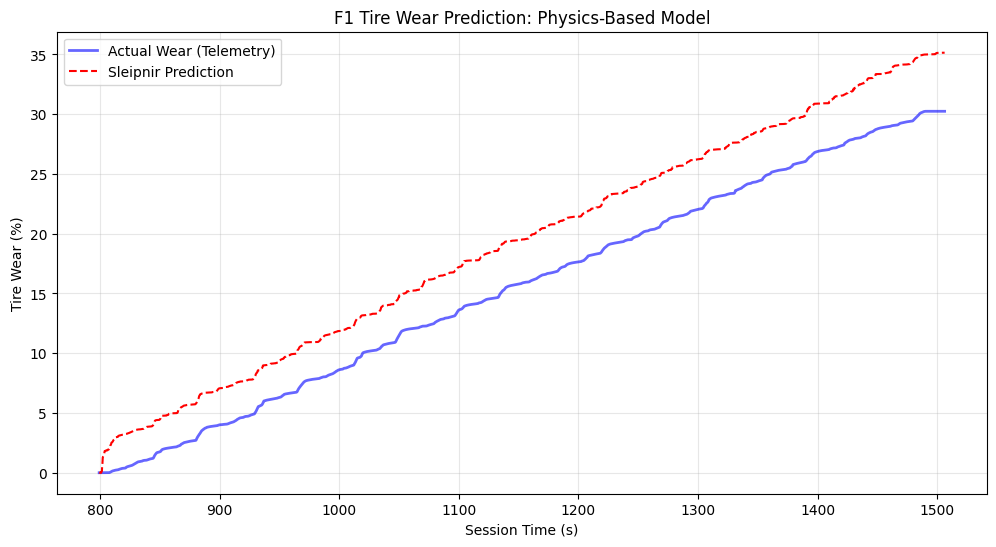

In [29]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

def load_all_packets(damage_file, tele_file, motion_file):
    def flatten(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'damage':
                        row['wear'] = d['m_carDamageData'][idx]['m_tyresWear'][0]
                    elif p_type == 'tele':
                        row['brake'] = d['m_carTelemetryData'][idx]['m_brake']
                        row['steer'] = d['m_carTelemetryData'][idx]['m_steer']
                        row['speed'] = d['m_carTelemetryData'][idx]['m_speed']
                        row['temp'] = d['m_carTelemetryData'][idx]['m_tyresSurfaceTemperature'][0]
                    elif p_type == 'motion':
                        row['g_lat'] = abs(d['m_carMotionData'][idx]['m_gForceLateral'])
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    df_d = flatten(damage_file, 'damage')
    df_t = flatten(tele_file, 'tele')
    df_m = flatten(motion_file, 'motion')

    # 시간 기준 병합
    combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_m, on='time', direction='nearest').dropna()
    return combined

def physics_feature_engineering(df):
    # 1. Stint 구분 (피트인 시 마모도가 뚝 떨어지는 지점 찾기)
    df = df.sort_values('time').reset_index(drop=True)
    df['stint'] = (df['wear'].diff() < -5).cumsum()

    # 2. 결과 저장을 위한 빈 리스트
    processed_chunks = []

    # 3. 각 Stint별로 루프를 돌며 누적 데이터 계산 (KeyError 방지)
    for s_id in df['stint'].unique():
        chunk = df[df['stint'] == s_id].copy()
        
        # 누적 에너지 계산: (물리량 * 속도)의 누적합
        chunk['cum_distance'] = (chunk['speed'] * 0.1).cumsum() # 주행 거리 추가 (10Hz 가정)
        chunk['cum_steer_work'] = (chunk['steer'].abs() * chunk['speed']).cumsum()
        chunk['cum_brake_work'] = (chunk['brake'] * chunk['speed']).cumsum()
        chunk['cum_lat_g_work'] = (chunk['g_lat'] * chunk['speed']).cumsum()
        chunk['cum_temp_work'] = chunk['temp'].cumsum()
        
        processed_chunks.append(chunk)

    # 다시 하나로 합치기
    final_df = pd.concat(processed_chunks).reset_index(drop=True)
    return final_df

# --- 파일 경로 설정 ---
path_damage = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl'
path_tele = r"D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl"
path_motion = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl'

# 1. 데이터 처리
combined = load_all_packets(path_damage, path_tele, path_motion)
combined = physics_feature_engineering(combined)


# 3. 학습/테스트 분할 (Stint 기반)
stints = combined['stint'].unique()
if len(stints) > 1:
    print(f"총 {len(stints)}개의 스틴트 발견. Stint 0으로 학습, Stint 1로 예측합니다.")
    train_df = combined[combined['stint'] == stints[0]].copy()
    test_df = combined[combined['stint'] == stints[1]].copy()
else:
    mid = len(combined) // 2
    train_df = combined.iloc[:mid].copy()
    test_df = combined.iloc[mid:].copy()

# 4. 모델 학습
features = ['cum_distance', 'cum_steer_work', 'cum_brake_work', 'cum_lat_g_work', 'cum_temp_work']
X_train = train_df[features]
y_train = train_df['wear']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 예측 및 시각화
test_df['predict'] = model.predict(test_df[features])

plt.figure(figsize=(12, 6))
plt.plot(test_df['time'], test_df['wear'], label='Actual Wear (Telemetry)', color='blue', alpha=0.6, linewidth=2)
plt.plot(test_df['time'], test_df['predict'], label='Sleipnir Prediction', color='red', linestyle='--')
plt.title("F1 Tire Wear Prediction: Physics-Based Model")
plt.xlabel("Session Time (s)")
plt.ylabel("Tire Wear (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

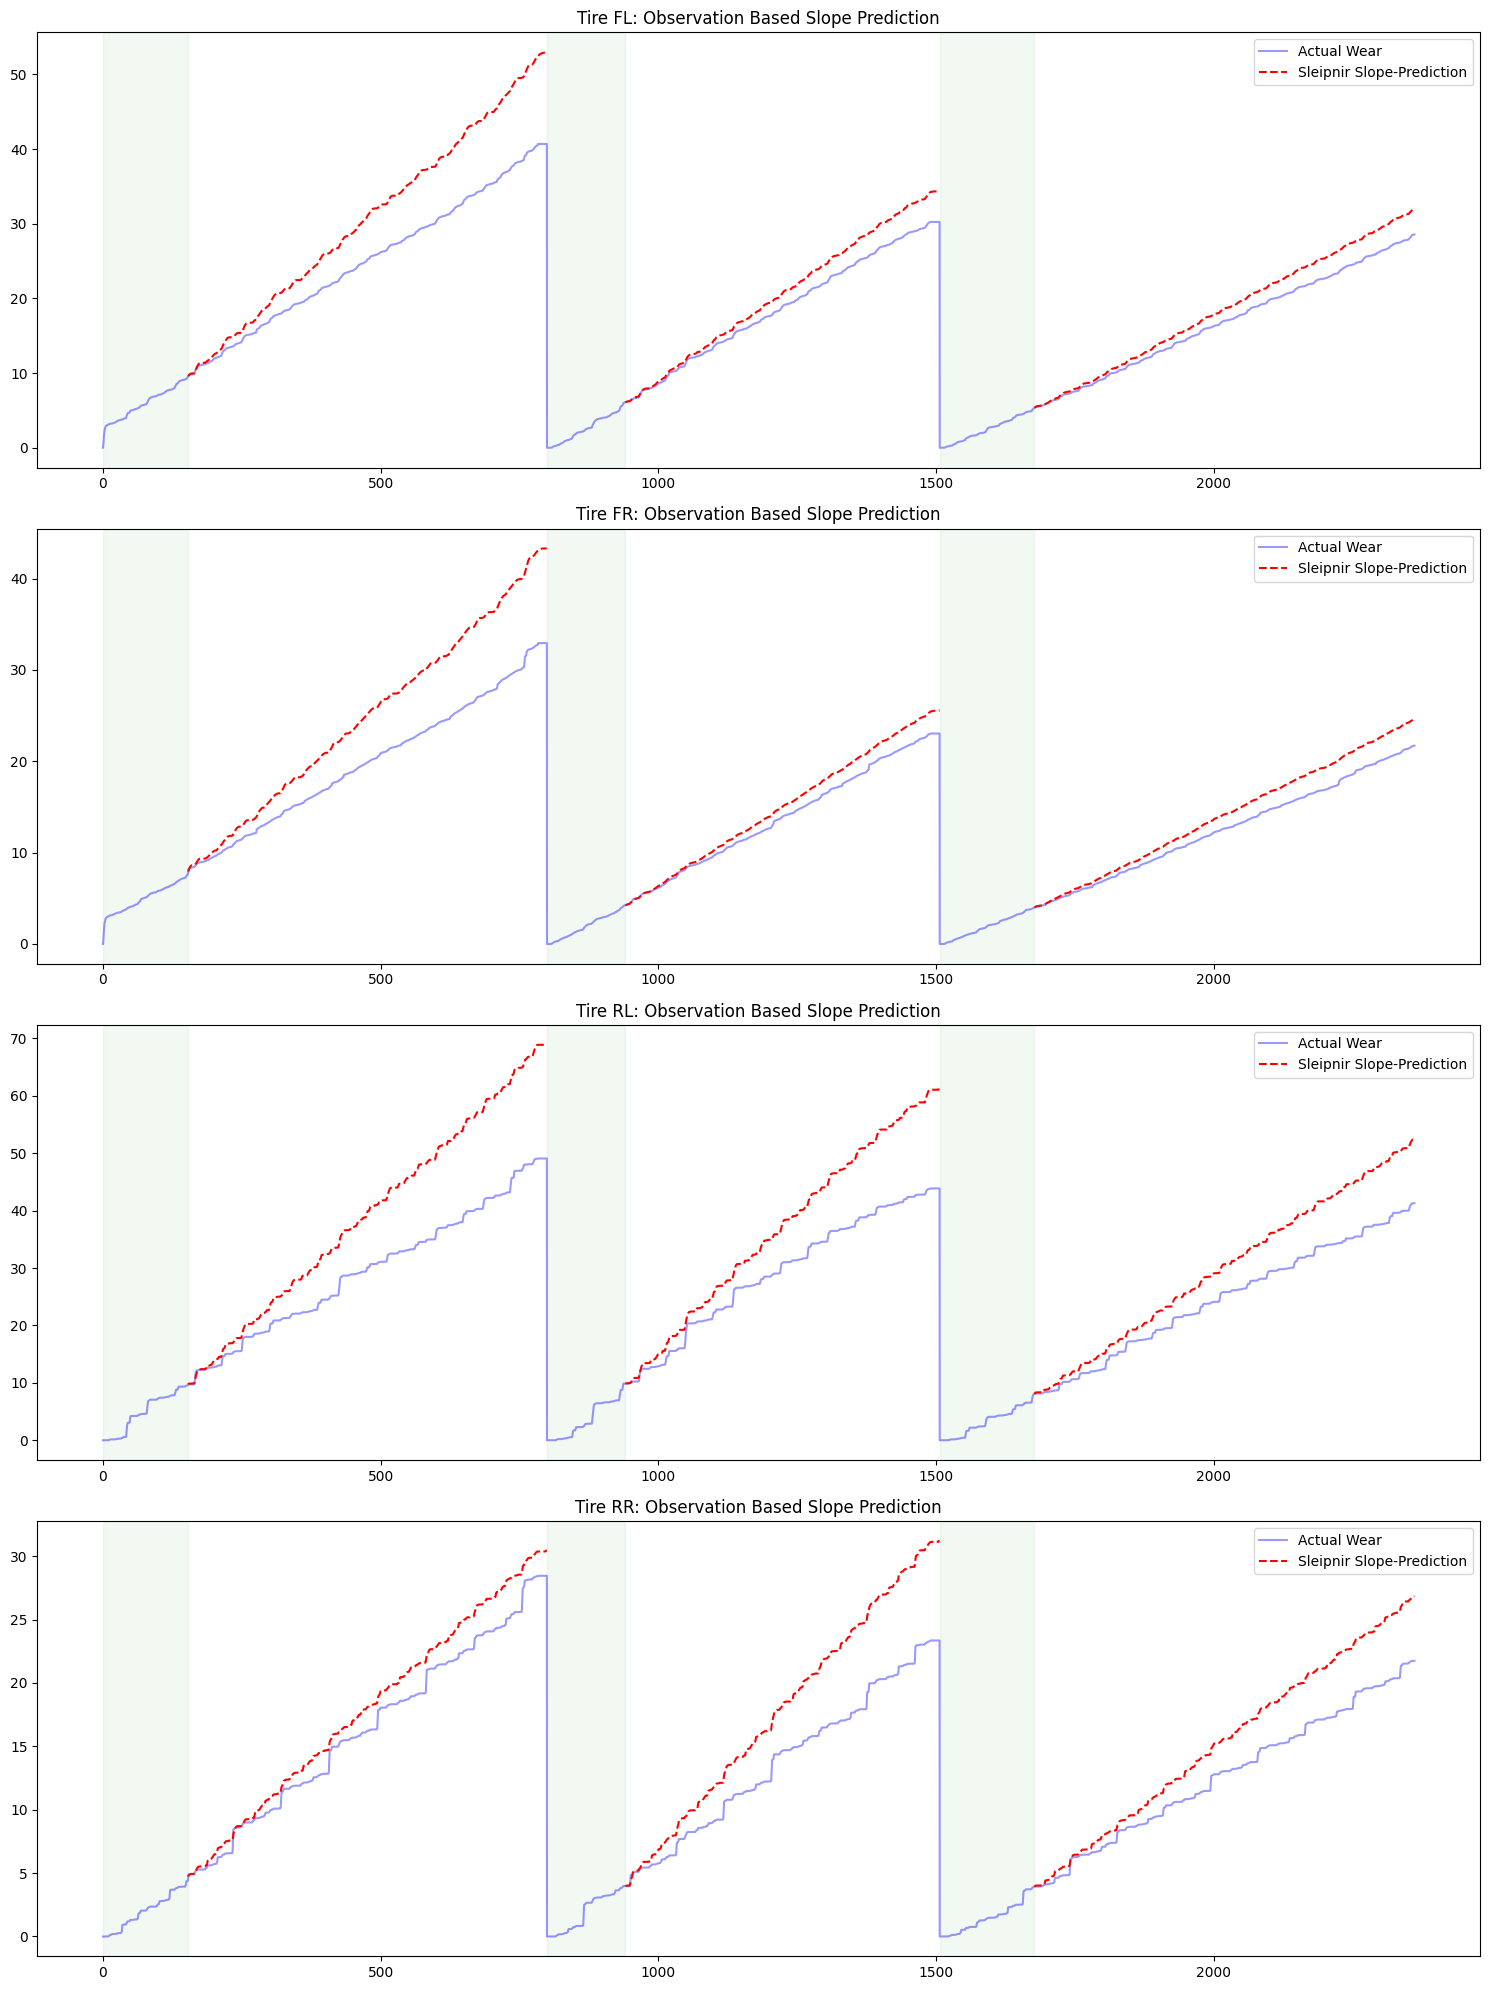

In [24]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_and_sync_final(damage_file, tele_file, motion_file):
    def flatten(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line); idx = d['m_header']['m_playerCarIndex']; t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'damage':
                        w = d['m_carDamageData'][idx]['m_tyresWear']
                        row['w_fl'], row['w_fr'], row['w_rl'], row['w_rr'] = w[0], w[1], w[2], w[3]
                    elif p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['brake'], row['steer'], row['speed'] = data['m_brake'], data['m_steer'], data['m_speed']
                        tmp = data['m_tyresSurfaceTemperature']
                        row['t_fl'], row['t_fr'], row['t_rl'], row['t_rr'] = tmp[0], tmp[1], tmp[2], tmp[3]
                    elif p_type == 'motion':
                        row['g_lat'] = abs(d['m_carMotionData'][idx]['m_gForceLateral'])
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    df_d, df_t, df_m = flatten(damage_file, 'damage'), flatten(tele_file, 'tele'), flatten(motion_file, 'motion')
    combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_m, on='time', direction='nearest').dropna()
    return combined

def run_delta_prediction_experiment(df, obs_ratio=0.3):
    wheels = ['fl', 'fr', 'rl', 'rr']
    # 학습에 사용할 순간 주행 변수 (누적값이 아님!)
    features_base = ['speed', 'brake', 'steer', 'g_lat']
    
    # 스틴트 구분
    df['stint'] = (df['w_fl'].diff() < -5).cumsum()
    
    fig, axes = plt.subplots(4, 1, figsize=(15, 20))
    
    for i, w in enumerate(wheels):
        target_col = f'w_{w}'
        temp_col = f't_{w}'
        wheel_features = features_base + [temp_col]
        
        df[f'pred_{w}'] = np.nan

        for s_id, stint_data in df.groupby('stint'):
            if len(stint_data) < 100: continue
            
            # 1. 구간 분리 (관찰 vs 예측)
            split_idx = int(len(stint_data) * obs_ratio)
            obs_set = stint_data.iloc[:split_idx].copy()
            future_set = stint_data.iloc[split_idx:].copy()
            
            # [핵심] 마모도 자체가 아닌 '프레임당 마모 변화량'을 타겟으로 설정
            obs_set['delta_w'] = obs_set[target_col].diff().fillna(0)
            
            # 2. 모델 학습 (물리적 인과관계를 위한 선형 회귀)
            model = LinearRegression()
            model.fit(obs_set[wheel_features], obs_set['delta_w'])
            
            # 3. 미래 예측 및 적분 (Integration)
            # 미래의 주행 데이터(X)를 넣어 예상되는 변화량(delta)들을 뽑아냄
            future_deltas = model.predict(future_set[wheel_features])
            
            # 관찰 구간 마지막 마모도에서 시작해서 변화량을 계속 더함
            current_w = obs_set[target_col].iloc[-1]
            predictions = []
            for d in future_deltas:
                current_w += max(0, d) # 마모는 줄어들지 않으므로 음수 방지
                predictions.append(current_w)
            
            df.loc[future_set.index, f'pred_{w}'] = predictions

        # 시각화
        axes[i].plot(df['time'], df[target_col], label='Actual Wear', color='blue', alpha=0.4)
        axes[i].plot(df['time'], df[f'pred_{w}'], label='Sleipnir Slope-Prediction', color='red', linestyle='--')
        
        # 관찰 구간(학습 데이터 사용 구간) 표시
        for s_id, group in df.groupby('stint'):
            obs_end_time = group['time'].iloc[int(len(group)*obs_ratio)-1]
            axes[i].axvspan(group['time'].min(), obs_end_time, color='green', alpha=0.05)

        axes[i].set_title(f"Tire {w.upper()}: Observation Based Slope Prediction")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# 실행 (경로는 유저님의 환경에 맞게)
combined = load_and_sync_final(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl',
                            r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl',
                            r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl')
run_delta_prediction_experiment(combined, obs_ratio=0.2)

📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...


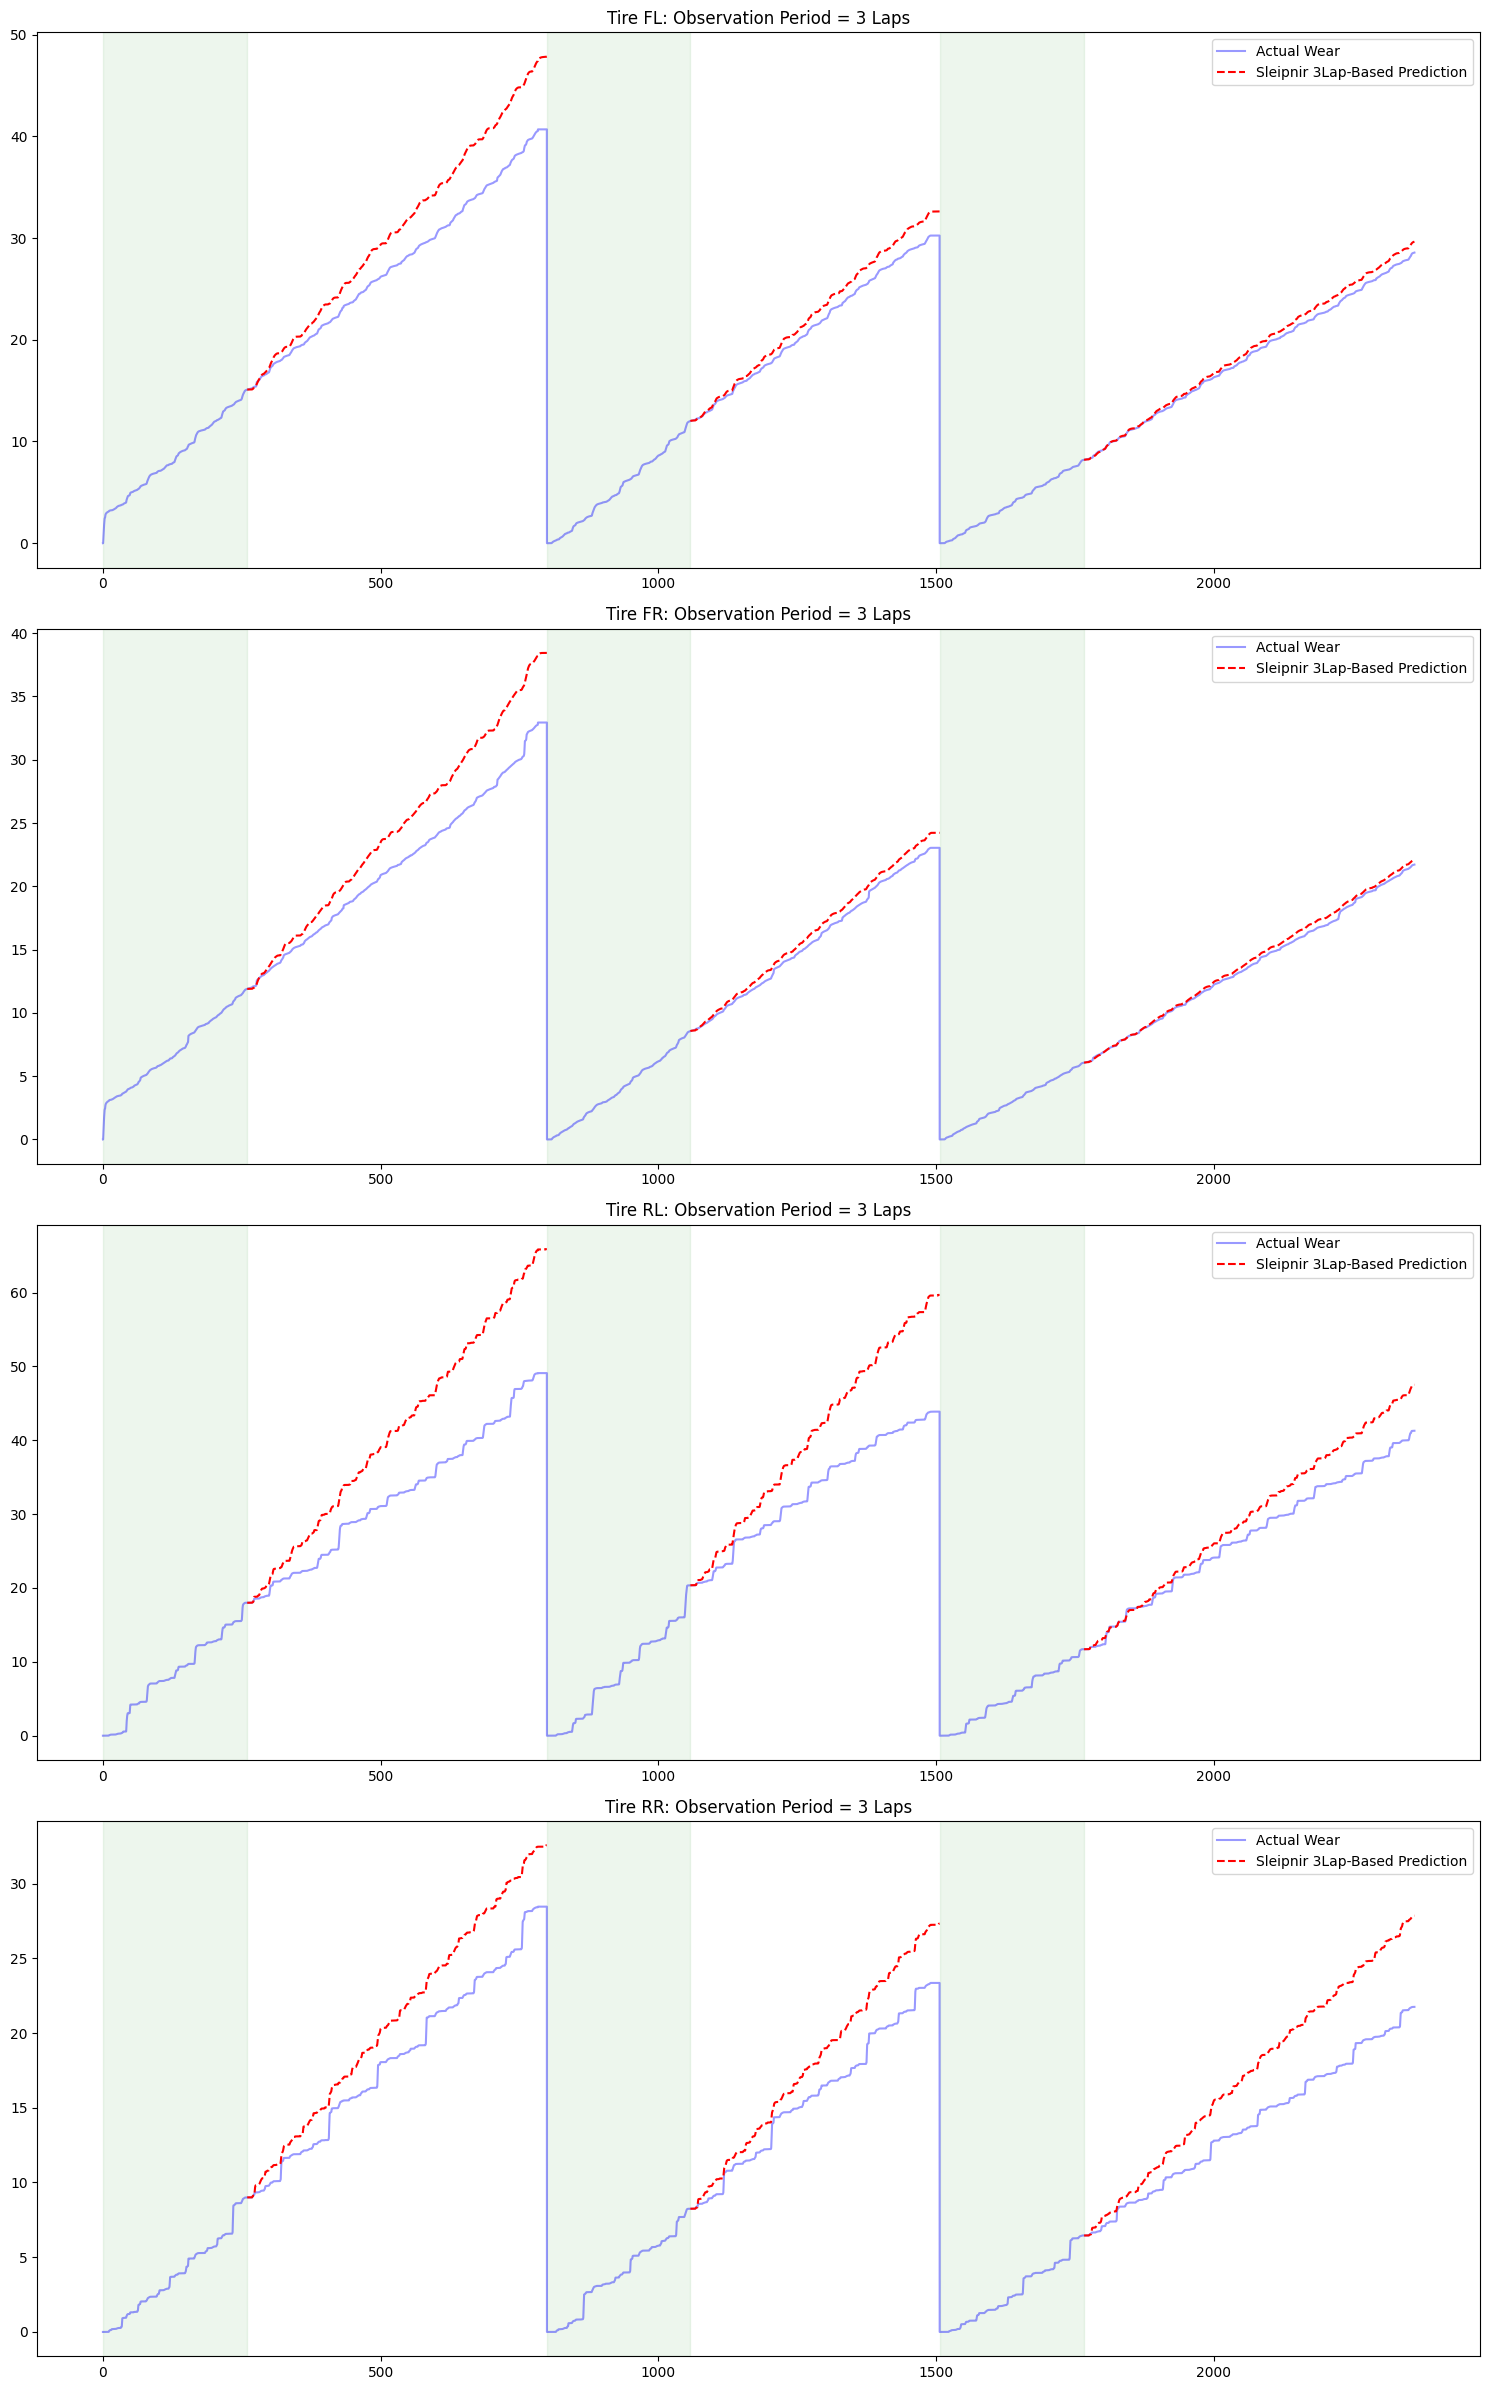

In [36]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_all_packets_with_laps(damage_file, tele_file, motion_file, lap_file):
    def flatten(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line); idx = d['m_header']['m_playerCarIndex']; t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'damage':
                        w = d['m_carDamageData'][idx]['m_tyresWear']
                        row['w_fl'], row['w_fr'], row['w_rl'], row['w_rr'] = w[0], w[1], w[2], w[3]
                    elif p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['brake'], row['steer'], row['speed'] = data['m_brake'], data['m_steer'], data['m_speed']
                        tmp = data['m_tyresSurfaceTemperature']
                        row['t_fl'], row['t_fr'], row['t_rl'], row['t_rr'] = tmp[0], tmp[1], tmp[2], tmp[3]
                    elif p_type == 'motion':
                        m_data = d['m_carMotionData'][idx]
                        row['g_lat'], row['g_lon'], row['g_vert'] = abs(m_data['m_gForceLateral']), abs(m_data['m_gForceLongitudinal']), abs(m_data['m_gForceVertical'])
                    elif p_type == 'lap':
                        # 현재 랩 번호 추출
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    print("📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...")
    df_d, df_t, df_m, df_l = flatten(damage_file, 'damage'), flatten(tele_file, 'tele'), flatten(motion_file, 'motion'), flatten(lap_file, 'lap')
    
    combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_m, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()
    return combined

def run_3lap_fixed_prediction(df, obs_laps=3):
    wheels = ['fl', 'fr', 'rl', 'rr']
    features_base = ['speed', 'brake', 'steer', 'g_lat', 'g_lon', 'g_vert']
    
    df['stint'] = (df['w_fl'].diff() < -5).cumsum()
    fig, axes = plt.subplots(4, 1, figsize=(15, 24))
    
    for i, w in enumerate(wheels):
        target_col = f'w_{w}'
        wheel_features = features_base + [f't_{w}']
        df[f'pred_{w}'] = np.nan

        for s_id, stint_data in df.groupby('stint'):
            if len(stint_data) < 100: continue
            
            # [핵심] 3랩 관찰 로직
            start_lap = stint_data['lap_num'].iloc[0]
            # 스틴트 시작 랩 번호 + obs_laps가 되는 시점을 찾음
            obs_mask = stint_data['lap_num'] < (start_lap + obs_laps)
            
            # 만약 스틴트 전체가 3랩보다 짧으면 절반만 사용 (예외 처리)
            if obs_mask.all():
                split_idx = len(stint_data) // 2
                obs_set = stint_data.iloc[:split_idx].copy()
                future_set = stint_data.iloc[split_idx:].copy()
            else:
                obs_set = stint_data[obs_mask].copy()
                future_set = stint_data[~obs_mask].copy()
            
            # 학습 및 델타 예측 (v8.0 로직 계승)
            obs_set['delta_w'] = obs_set[target_col].diff().fillna(0)
            model = LinearRegression()
            model.fit(obs_set[wheel_features], obs_set['delta_w'])
            
            future_deltas = model.predict(future_set[wheel_features])
            current_w = obs_set[target_col].iloc[-1]
            predictions = []
            for d in future_deltas:
                current_w += max(0, d)
                predictions.append(current_w)
            
            df.loc[future_set.index, f'pred_{w}'] = predictions

        # 시각화 (동일)
        axes[i].plot(df['time'], df[target_col], label='Actual Wear', color='blue', alpha=0.4)
        axes[i].plot(df['time'], df[f'pred_{w}'], label=f'Sleipnir {obs_laps}Lap-Based Prediction', color='red', linestyle='--')
        
        # 3랩 관찰 종료 시점 시각화
        for s_id, group in df.groupby('stint'):
            start_lap = group['lap_num'].iloc[0]
            obs_end_data = group[group['lap_num'] < (start_lap + obs_laps)]
            if not obs_end_data.empty:
                axes[i].axvspan(group['time'].min(), obs_end_data['time'].max(), color='green', alpha=0.07)

        axes[i].set_title(f"Tire {w.upper()}: Observation Period = {obs_laps} Laps")
        axes[i].legend()

    plt.tight_layout()
    plt.show()

# --- 실행부 ---
# path_lap = r'D:\...\record_lap.jsonl' # 랩 데이터 경로 추가 필요
combined_v9 = load_all_packets_with_laps(r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl',
                                        r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl',
                                          r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl',
                                        r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_lap.jsonl')
run_3lap_fixed_prediction(combined_v9, obs_laps=3)